# 02. Xây dựng Behavioral Representation  
**Mục tiêu** biến mỗi order thành một vector đặc trưng hành vi.  
**Đơn vị phân tích** chọn **order-level** thay vì user.  
Vector đặc trưng gồm 3 nhóm:
1. **Cơ cấu ngành hàng (department mix)** - tỷ trọng sản phẩm mỗi ngành hàng trong giỏ hàng (21 part)  
2. **Đặc điểm giỏ hàng** - kích thước giỏ hàng (log), có mua cuối tuần không,...  
3. **Nhịp thời gian trong ngày** - khung giờ mua

In [1]:
print("Hi")

Hi


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df_clean = pd.read_parquet('data/cleaned_items.parquet')
order_lvl = pd.read_parquet('data/order_level.parquet')
print(df_clean.shape, order_lvl.shape)
print('Số khách hàng (user_id) duy nhất:', order_lvl['user_id'].nunique())

(1048574, 12) (103761, 8)
Số khách hàng (user_id) duy nhất: 70268


## 1. Đặc trưng tần suất, quy mô giỏ hàng, trung thành, nhịp thời gian (mức khách hàng)

In [9]:
order_lvl['weekend'] = order_lvl['order_dow'].isin([0, 6]).astype(int)   # 0=CN, 6=T7
order_lvl['startweek'] = (order_lvl['order_dow'] == 1).astype(int)       # T2

order_lvl['hour_bucket'] = pd.cut(
    order_lvl['order_hour_of_day'],
    bins=[-1, 5, 9, 13, 17, 21, 24],
    labels=['night', 'morning', 'noon', 'afternoon', 'evening', 'late_evening']
)
hb = pd.get_dummies(order_lvl['hour_bucket'], prefix='hb').astype(int)
hb_cols = list(hb.columns)
order_lvl_hb = pd.concat([order_lvl, hb], axis=1)

user_behavior = order_lvl_hb.groupby('user_id').agg(
    n_orders_observed=('order_id', 'count'),        # tần suất: số đơn được ghi nhận
    max_order_number=('order_number', 'max'),        # thâm niên: đơn thứ mấy gần nhất quan sát được
    avg_basket_size=('basket_size', 'mean'),          # quy mô giỏ hàng
    avg_reorder_rate=('reorder_rate', 'mean'),        # trung thành
    avg_days_between_orders=('days_since_prior_order', 'mean'),  # nhịp mua lặp lại
    weekend_ratio=('weekend', 'mean'),                 # nhịp thời gian: cuối tuần
    startweek_ratio=('startweek', 'mean'),             # nhịp thời gian: đầu tuần
    **{c: (c, 'mean') for c in hb_cols}                # nhịp thời gian: khung giờ
).reset_index()

print('Số khách hàng:', user_behavior.shape[0])
user_behavior.head()

Số khách hàng: 70268


,user_id,n_orders_observed,max_order_number,avg_basket_size,avg_reorder_rate,avg_days_between_orders,weekend_ratio,startweek_ratio,hb_night,hb_morning,hb_noon,hb_afternoon,hb_evening,hb_late_evening
0,3,2,4,7.0,0.266667,14.5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,7,1,3,24.0,0.833333,30.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,10,1,4,30.0,0.433333,14.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13,1,7,10.0,0.600000,7.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,17,1,21,5.0,1.000000,4.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [10]:
user_behavior['is_new_customer'] = (
    (user_behavior['n_orders_observed'] == 1) & (user_behavior['max_order_number'] == 1)
).astype(int)

print('Số khách hàng mới (chỉ có đúng 1 đơn = đơn đầu tiên):', user_behavior['is_new_customer'].sum(),
      f"({user_behavior['is_new_customer'].mean()*100:.1f}% tổng khách hàng)")

Số khách hàng mới (chỉ có đúng 1 đơn = đơn đầu tiên): 4330 (6.2% tổng khách hàng)


# 2. department

In [11]:
dept_counts_user = df_clean.pivot_table(index='user_id', columns='department', values='product_id',
                                         aggfunc='count', fill_value=0)
dept_share_user = dept_counts_user.div(dept_counts_user.sum(axis=1), axis=0)
dept_cols = list(dept_share_user.columns)

# (a) Ngành hàng khách mua nhiều nhất — 1 nhãn duy nhất, không phải 21 tỷ trọng
primary_department = dept_share_user.idxmax(axis=1)

# (b) Độ đa dạng ngành hàng (entropy chuẩn hoá 0-1): 0 = chỉ mua 1 ngành, 1 = mua dàn trải đều mọi ngành
def normalized_entropy(row):
    p = row[row > 0]
    if len(p) <= 1:
        return 0.0
    ent = -(p * np.log(p)).sum()
    return ent / np.log(len(dept_cols))

department_diversity = dept_share_user.apply(normalized_entropy, axis=1)

# (c) Tỷ trọng 2 ngành hàng thiết yếu lớn nhất thị trường (produce, dairy eggs) — giữ riêng vì có ý nghĩa kinh doanh rõ
produce_share = dept_share_user.get('produce', pd.Series(0, index=dept_share_user.index))
dairy_share = dept_share_user.get('dairy eggs', pd.Series(0, index=dept_share_user.index))

dept_summary = pd.DataFrame({
    'primary_department': primary_department,
    'department_diversity': department_diversity,
    'produce_share': produce_share,
    'dairy_share': dairy_share,
}).reset_index()

print('Department được nén từ', len(dept_cols), 'chiều xuống còn 1 nhãn (primary_department) + 3 chỉ số numeric.')
dept_summary.head()

Department được nén từ 20 chiều xuống còn 1 nhãn (primary_department) + 3 chỉ số numeric.


,user_id,primary_department,department_diversity,produce_share,dairy_share
0,3,dairy eggs,0.612133,0.214286,0.214286
1,7,beverages,0.664035,0.083333,0.166667
2,10,produce,0.489684,0.433333,0.166667
3,13,dairy eggs,0.502311,0.300000,0.300000
4,17,alcohol,0.537244,0.200000,0.200000


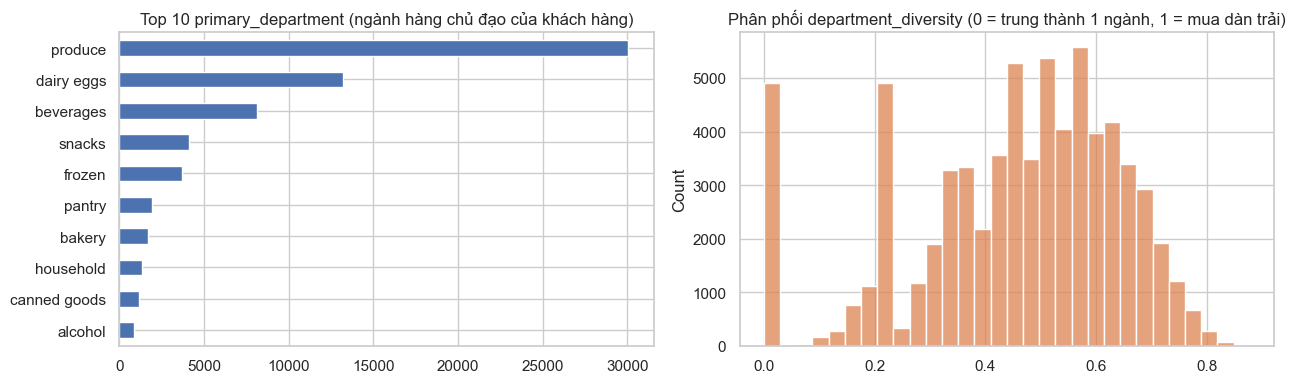

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
primary_department.value_counts().head(10).plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 10 primary_department (ngành hàng chủ đạo của khách hàng)')
axes[0].invert_yaxis()

sns.histplot(department_diversity, bins=30, ax=axes[1], color='#DD8452')
axes[1].set_title('Phân phối department_diversity (0 = trung thành 1 ngành, 1 = mua dàn trải)')
plt.tight_layout()
plt.show()

# 3 Feature

In [13]:
user_feat = user_behavior.merge(dept_summary, on='user_id', how='left')

# Biến đổi log cho các đại lượng lệch phải (chuẩn bị cho chuẩn hoá/PCA/clustering)
user_feat['log_max_order_number'] = np.log1p(user_feat['max_order_number'])
user_feat['log_avg_basket_size'] = np.log1p(user_feat['avg_basket_size'])
user_feat['log_avg_days_between_orders'] = np.log1p(
    user_feat['avg_days_between_orders'].fillna(user_feat['avg_days_between_orders'].median())
)

print('Tổng số khách hàng:', user_feat.shape[0], '| Tổng số cột:', user_feat.shape[1])
user_feat.head()

Tổng số khách hàng: 70268 | Tổng số cột: 22


,user_id,n_orders_observed,max_order_number,avg_basket_size,avg_reorder_rate,avg_days_between_orders,weekend_ratio,startweek_ratio,hb_night,hb_morning,...,hb_evening,hb_late_evening,is_new_customer,primary_department,department_diversity,produce_share,dairy_share,log_max_order_number,log_avg_basket_size,log_avg_days_between_orders
0,3,2,4,7.0,0.266667,14.5,0.0,0.0,0.0,0.0,...,1.0,0.0,0,dairy eggs,0.612133,0.214286,0.214286,1.609438,2.079442,2.740840
1,7,1,3,24.0,0.833333,30.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0,beverages,0.664035,0.083333,0.166667,1.386294,3.218876,3.433987
2,10,1,4,30.0,0.433333,14.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,produce,0.489684,0.433333,0.166667,1.609438,3.433987,2.708050
3,13,1,7,10.0,0.600000,7.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0,dairy eggs,0.502311,0.300000,0.300000,2.079442,2.397895,2.079442
4,17,1,21,5.0,1.000000,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0,alcohol,0.537244,0.200000,0.200000,3.091042,1.791759,1.609438


## 4. Visualize behavioral representation  


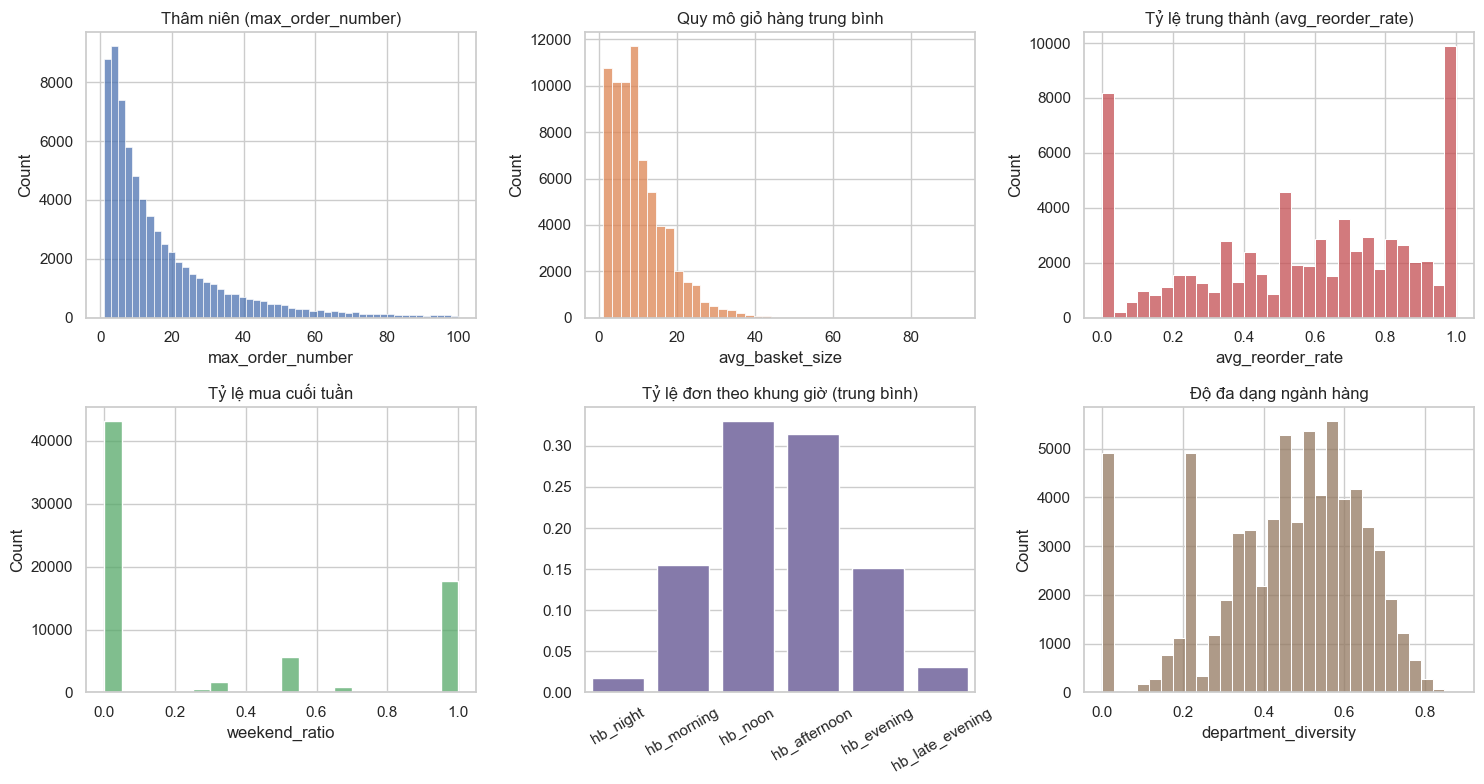

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.histplot(user_feat['max_order_number'], bins=50, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Thâm niên (max_order_number)')

sns.histplot(user_feat['avg_basket_size'], bins=40, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Quy mô giỏ hàng trung bình')

sns.histplot(user_feat['avg_reorder_rate'], bins=30, ax=axes[0,2], color='#C44E52')
axes[0,2].set_title('Tỷ lệ trung thành (avg_reorder_rate)')

sns.histplot(user_feat['weekend_ratio'], bins=20, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Tỷ lệ mua cuối tuần')

sns.barplot(x=hb_cols, y=[user_feat[c].mean() for c in hb_cols], ax=axes[1,1], color='#8172B2')
axes[1,1].set_title('Tỷ lệ đơn theo khung giờ (trung bình)')
axes[1,1].tick_params(axis='x', rotation=30)

sns.histplot(user_feat['department_diversity'], bins=30, ax=axes[1,2], color='#937860')
axes[1,2].set_title('Độ đa dạng ngành hàng')

plt.tight_layout()
plt.show()

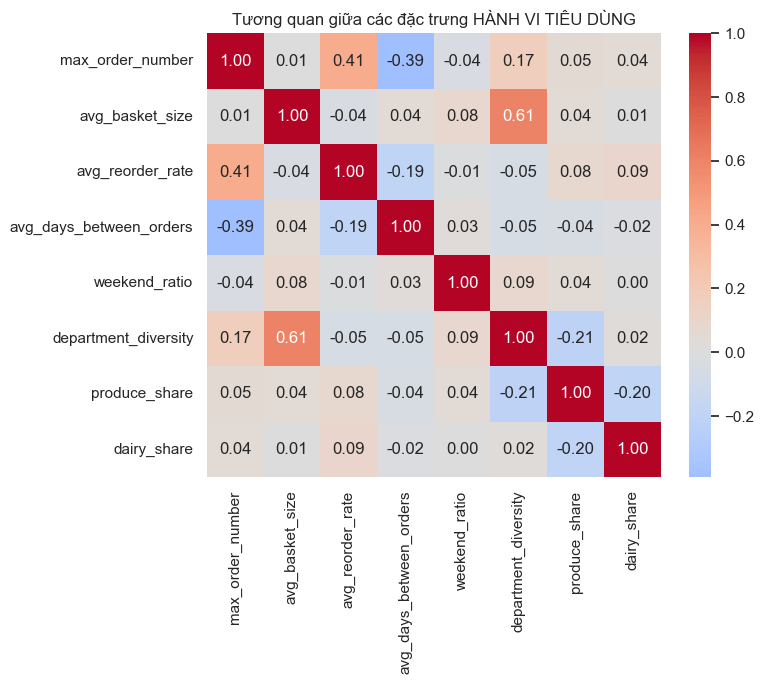

In [15]:
behavior_cols_for_corr = ['max_order_number', 'avg_basket_size', 'avg_reorder_rate',
                          'avg_days_between_orders', 'weekend_ratio', 'department_diversity',
                          'produce_share', 'dairy_share']
corr = user_feat[behavior_cols_for_corr].corr()
fig, ax = plt.subplots(figsize=(8,7))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Tương quan giữa các đặc trưng HÀNH VI TIÊU DÙNG')
plt.tight_layout()
plt.show()

#### 3.2 Phân phối các feature

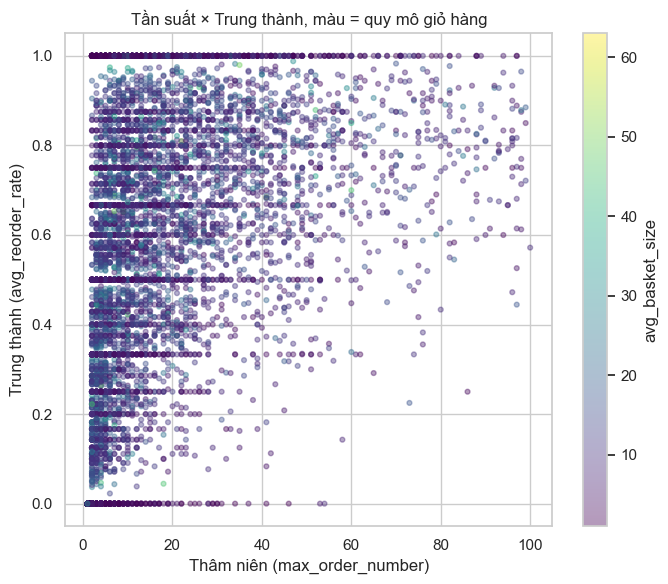

In [16]:
fig, ax = plt.subplots(figsize=(7,6))
sample = user_feat.sample(min(8000, len(user_feat)), random_state=42)
sc = ax.scatter(sample['max_order_number'], sample['avg_reorder_rate'],
                 c=sample['avg_basket_size'], cmap='viridis', alpha=0.4, s=12)
ax.set_xlabel('Thâm niên (max_order_number)')
ax.set_ylabel('Trung thành (avg_reorder_rate)')
ax.set_title('Tần suất × Trung thành, màu = quy mô giỏ hàng')
plt.colorbar(sc, label='avg_basket_size')
plt.tight_layout()
plt.show()

=> phần lớn đơn hàng diễn ra vào noon/afternoon, tỷ lệ đơn cuối tuần và đầu tuần chiếm 50% tổng số đơn

In [17]:
top_primary_depts = user_feat['primary_department'].value_counts().head(5).index.tolist()
user_feat['primary_department_grouped'] = user_feat['primary_department'].where(
    user_feat['primary_department'].isin(top_primary_depts), 'other'
)
primary_dummies = pd.get_dummies(user_feat['primary_department_grouped'], prefix='primary').astype(int)
primary_dummy_cols = list(primary_dummies.columns)
user_feat = pd.concat([user_feat, primary_dummies], axis=1)

print(f'primary_department được gộp thành top {len(top_primary_depts)} nhóm + "other" -> {len(primary_dummy_cols)} cột nhị phân')
print(primary_dummy_cols)

primary_department được gộp thành top 5 nhóm + "other" -> 6 cột nhị phân
['primary_beverages', 'primary_dairy eggs', 'primary_frozen', 'primary_other', 'primary_produce', 'primary_snacks']


# 4. Chuẩn hóa

In [18]:
from sklearn.preprocessing import StandardScaler

# Feature set clustering: HÀNH VI TIÊU DÙNG làm trục chính, department chỉ góp 3 numeric + nhóm primary (nén gọn)
behavior_feature_cols = [
    'log_max_order_number',      # thâm niên / tần suất
    'log_avg_basket_size',       # quy mô giỏ hàng
    'avg_reorder_rate',          # trung thành
    'log_avg_days_between_orders',  # nhịp mua lặp lại
    'weekend_ratio', 'startweek_ratio',  # nhịp tuần
] + hb_cols + [                  # nhịp khung giờ trong ngày
    'department_diversity', 'produce_share', 'dairy_share',  # sở thích ngành hàng (nén gọn)
] + primary_dummy_cols           # ngành hàng chủ đạo (nén gọn, không phải 21 chiều)

X_user = user_feat[behavior_feature_cols].fillna(0).values
scaler_user = StandardScaler()
X_user_scaled = scaler_user.fit_transform(X_user)

print('Ma trận đặc trưng HÀNH VI dùng để clustering:', X_user_scaled.shape)
print(f'Số chiều: {len(behavior_feature_cols)}  (so với 28 chiều bản cũ, trong đó riêng department đã chiếm 21 chiều)')
print(behavior_feature_cols)

Ma trận đặc trưng HÀNH VI dùng để clustering: (70268, 21)
Số chiều: 21  (so với 28 chiều bản cũ, trong đó riêng department đã chiếm 21 chiều)
['log_max_order_number', 'log_avg_basket_size', 'avg_reorder_rate', 'log_avg_days_between_orders', 'weekend_ratio', 'startweek_ratio', 'hb_night', 'hb_morning', 'hb_noon', 'hb_afternoon', 'hb_evening', 'hb_late_evening', 'department_diversity', 'produce_share', 'dairy_share', 'primary_beverages', 'primary_dairy eggs', 'primary_frozen', 'primary_other', 'primary_produce', 'primary_snacks']


In [ ]:
import json, os
os.makedirs('data', exist_ok=True)

user_feat.to_parquet('data/user_features.parquet', index=False)
np.save('data/X_user_scaled.npy', X_user_scaled)

with open('data/feature_cols_user.json', 'w') as f:
    json.dump({
        'behavior_feature_cols': behavior_feature_cols,
        'hb_cols': hb_cols,
        'primary_dummy_cols': primary_dummy_cols,
        'consumption_cols': ['max_order_number', 'avg_basket_size', 'avg_reorder_rate', 'avg_days_between_orders'],
        'timing_cols': ['weekend_ratio', 'startweek_ratio'] + hb_cols,
        'department_cols': ['department_diversity', 'produce_share', 'dairy_share'] + primary_dummy_cols,
    }, f, indent=2, ensure_ascii=False)

print('Đã lưu:')
print(' - data/user_features.parquet   :', user_feat.shape, '(mức khách hàng)')
print(' - data/X_user_scaled.npy       :', X_user_scaled.shape)
print(' - data/feature_cols_user.json')

Đã lưu:
 - data/user_features.parquet   : (70268, 29) (mức khách hàng)
 - data/X_user_scaled.npy       : (70268, 21)
 - data/feature_cols_user.json
